In [4]:
# ============ RECALL Week 4 Day 2 -WARMUP ============
# 1.difference between Random Forest and Gradient Boosting :
  # Random forest has n trees built in parallel on bootstrap samples. Then the predictions are averaged .
  # Gradient Boosting: Each new tree is built on Pseudo_residuals from previous trees and scaled with a learning_rate.

# 2. learning_rate do in XGBoost:
  # Learning Rate scales the output of Pseudo-residuals, controls step size. Smaller steps = more conservative updates = needs more trees to converge.

# 3. XGBoost score on Titanic and which params are essential
  # 0.839 - n_estimators=500, learning_rate= 0.01

# =======================================

# **week4/ day 3**

-	LightGBM: why it is faster histogram-based splits, leaf-wise growth
-	Train LightGBM on House Prices, compare training speed to XGBoost
-	Plot learning curves: training vs validation score as n_estimators grows


## Task 1
### Histogram-based splits
1. Instead of scanning every possible split value for continuous features,
2. LightGBM buckets values into discrete bins (histograms). This reduces
the number of split candidates from O(n) to O(bins), significantly
cutting computation time and memory usage, especially on large datasets.

### Leaf-wise vs Level-wise growth
- Level-wise (XGBoost):
    1. Grows all nodes at the same depth before going deeper.Balanced trees, slower on large datasets.

- Leaf-wise (LightGBM):
    1. Always splits the leaf with the highest loss reduction
first, regardless of depth. Faster convergence and better accuracy on large
datasets.
    2. Tradeoff: can overfit on small datasets - controlled via
`min_data_in_leaf` and `max_depth`.

### Task 2 : Load House Prices dataset


In [5]:
import pandas as pd
import numpy as np

In [6]:
df = pd.read_csv("train.csv")

In [7]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [9]:
null_cols =df.isnull().sum()
null_cols[null_cols>0].sort_values(ascending=False)

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageType,81
GarageYrBlt,81
GarageFinish,81


In [10]:
#dropping cols > 50% null count
df = df.drop(columns=["PoolQC", "MiscFeature", "Alley", "Fence", "MasVnrType"])

In [11]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,0,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,...,0,0,0,0,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,...,0,0,0,0,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,...,272,0,0,0,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,...,0,0,0,0,0,12,2008,WD,Normal,250000


In [12]:
# fill na values of numeric columns with median

for col in df.select_dtypes(include='number').columns:
  df[col] =df[col].fillna(df[col].median())

In [13]:
# Categorical columns with mode
for col in df.select_dtypes(include="object").columns:
  df[col] = df[col].fillna(df[col].mode()[0])

In [14]:
df.isnull().sum().sum()

np.int64(0)

In [15]:
null_cols = df.isnull().sum()
null_cols[null_cols > 0].sort_values(ascending=False)

,0


In [16]:
print(df['FireplaceQu'].dtype)

object


In [17]:
print(df['FireplaceQu'].mode()[0])

Gd


In [18]:
df.select_dtypes(include='object').columns

Index(['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional',
       'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
       'PavedDrive', 'SaleType', 'SaleCondition'],
      dtype='object')

In [19]:
#encode categoricals with pd.get_dummies()
df = pd.get_dummies(df)

In [20]:
pd.get_dummies(df)

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1,60,65.0,8450,7,5,2003,2003,196.0,706,...,False,False,False,True,False,False,False,False,True,False
1,2,20,80.0,9600,6,8,1976,1976,0.0,978,...,False,False,False,True,False,False,False,False,True,False
2,3,60,68.0,11250,7,5,2001,2002,162.0,486,...,False,False,False,True,False,False,False,False,True,False
3,4,70,60.0,9550,7,5,1915,1970,0.0,216,...,False,False,False,True,True,False,False,False,False,False
4,5,60,84.0,14260,8,5,2000,2000,350.0,655,...,False,False,False,True,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,62.0,7917,6,5,1999,2000,0.0,0,...,False,False,False,True,False,False,False,False,True,False
1456,1457,20,85.0,13175,6,6,1978,1988,119.0,790,...,False,False,False,True,False,False,False,False,True,False
1457,1458,70,66.0,9042,7,9,1941,2006,0.0,275,...,False,False,False,True,False,False,False,False,True,False
1458,1459,20,68.0,9717,5,6,1950,1996,0.0,49,...,False,False,False,True,False,False,False,False,True,False


In [21]:
X = df.drop(columns=['SalePrice'])
y = df['SalePrice']

In [22]:
print(f"X shape: {X.shape}")
print(f"\ny shape: {y.shape}")

X shape: (1460, 272)

y shape: (1460,)


In [23]:
import lightgbm as lgb
print(lgb.__version__)

4.6.0


## Task 3 : Train LightGBM vs XGBoost
1. Same features, same CV compare both training time using time.time() before and after.
2. Record the speed difference.

In [24]:
import time
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.model_selection import cross_val_score

start = time.time()

# LightGBM
lgb = LGBMRegressor()
lgb_accuracy = cross_val_score(lgb, X,y, cv=5, scoring='neg_mean_squared_error')
print(f"Accuracy LGBMRegressor: {lgb_accuracy}")
print(f"Mean accuracy LGBM :{np.mean(lgb_accuracy)}")

end = time.time()
print(f"Time taken : {end - start:.2f}s")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001520 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3414
[LightGBM] [Info] Number of data points in the train set: 1168, number of used features: 175
[LightGBM] [Info] Start training from score 180717.091610
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001062 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3424
[LightGBM] [Info] Number of data points in the train set: 1168, number of used features: 171
[LightGBM] [Info] Start training from score 180407.575342
[LightGBM] [Warnin

In [25]:
start = time.time()
#XGBoost
bst = XGBRegressor()
xgb_accuracy = cross_val_score(bst, X,y, cv=5, scoring='neg_mean_squared_error')
print(f"Accuracy XGBRegressor: {xgb_accuracy}")
print(f"Mean accuracy XGB :{np.mean(xgb_accuracy)}")

end = time.time()

print(f"Time taken : {end - start:.2f}s")

Accuracy XGBRegressor: [-7.10446144e+08 -1.13396058e+09 -1.00119418e+09 -4.67361344e+08
 -1.01245088e+09]
Mean accuracy XGB :-865082624.0
Time taken : 14.47s


In [26]:
print(f"LGBM RMSE: {np.sqrt(abs(np.mean(lgb_accuracy))):.0f}")
print(f"XGB RMSE: {np.sqrt(abs(np.mean(xgb_accuracy))):.0f}")

LGBM RMSE: 28809
XGB RMSE: 29412


1. Speed: LightGBM 2.00s vs XGBoost 4.59s
- 2.3x faster due to histogram-based splits.


2. Accuracy:
    1. LightGBM RMSE 28,809 v/s
    2. XGBoost 29,412
- RMSE : on average LightGBM's house price prediction is off by ~$28,809. So less error than XGBosst comparatively.

## Task 4 - Learning curves
1. For n_estimators in range [10, 50, 100, 200, 500]
- plot training vs validation score as it grows.
- Two lines on same plot.

In [32]:
from sklearn.model_selection import cross_validate

estimators = [10, 50, 100, 200, 500]
train_scores = []
val_scores = []

for i in estimators:
  lgb = LGBMRegressor(n_estimators=i)
  results = cross_validate(lgb, X, y, cv=5,scoring='neg_mean_squared_error',return_train_score=True)


  train_scores.append(np.mean(results['train_score']))  # training scores per fold
  val_scores.append(np.mean(results['test_score']))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001117 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3414
[LightGBM] [Info] Number of data points in the train set: 1168, number of used features: 175
[LightGBM] [Info] Start training from score 180717.091610
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001177 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3424
[LightGBM] [Info] Number of data points in the train set: 1168, number of used features: 171
[LightGBM] [Info] Start training from score 180407.575342
[LightGBM] [Warnin

In [33]:
print(train_scores)

[np.float64(-1489629333.2252064), np.float64(-287396747.69114476), np.float64(-140820695.45272815), np.float64(-48696240.52247545), np.float64(-4635093.588418385)]


In [34]:
print(val_scores)

[np.float64(-1780906489.3398812), np.float64(-823291680.9123356), np.float64(-829934926.7675797), np.float64(-864995165.741799), np.float64(-853580585.6867621)]


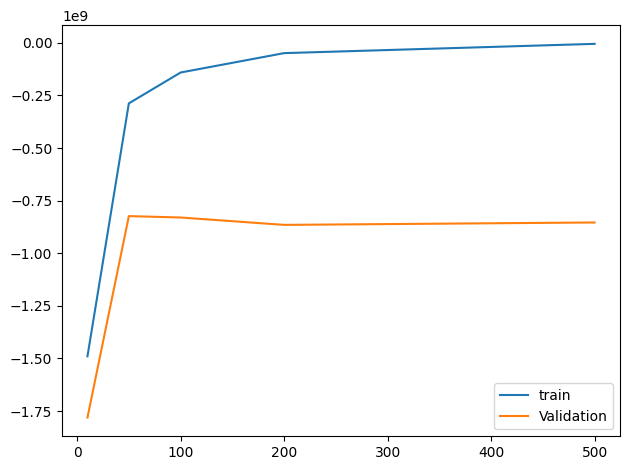

In [38]:
from matplotlib import legend
import matplotlib.pyplot as plt

fig,ax = plt.subplots()
ax.plot(estimators,train_scores, label='train')
ax.plot(estimators,val_scores,label='Validation')
ax.legend()

plt.tight_layout()
plt.show()

## Task 5 - Markdown
## When to choose LightGBM over XGBoost

Choose LightGBM when:
- Dataset is large (100k+ rows): histogram-based splits and leaf-wise
  growth make it significantly faster than XGBoost
- Training speed matters: LightGBM was 2.3x faster on House Prices
  (2.00s vs 4.59s)
- Memory is constrained: bin-based approach uses less memory than
  XGBoost's exact split method

Stick with XGBoost when:
- Dataset is small: speed advantage disappears, XGBoost more battle-tested
- Interpretability matters more: level-wise growth produces more
  balanced, predictable trees
- You need fine-grained regularisation control

Rule of thumb: small/medium dataset → XGBoost.
Large dataset or speed-critical → LightGBM.